# 분류 ② 결정트리

**오늘의 질문**: 모델이 왜 그렇게 판단했는지, 사람이 읽을 수 있을까?

로지스틱 회귀와 KNN은 판단 근거를 꺼내 보기 어려웠음. 결정 트리는 다름.

### 오늘 끝나면 할 수 있는 것

1. 트리 상자 하나를 읽고, 꽃 한 송이가 어느 잎으로 가는지 손으로 따라가기
2. 두 후보 질문 중 어느 쪽이 더 좋은 질문인지 숫자로 말하기
3. `max_depth`를 바꿨을 때 **외운 문제 점수**와 **처음 보는 문제 점수**가 왜 따로 노는지 설명하기
4. 선택이 끝나기 전에 최종 평가 데이터를 열지 않는 이유 말하기
5. `feature_importances_`가 0인 피처를 "쓸모없다"고 읽으면 왜 틀리는지 설명하기

### 오늘의 흐름

| Act | 무엇을 |
|:--:|---|
| 1 | 질문 경로 읽기 |
| 2 | 좋은 질문 고르기 (Count → Rate → 불순도) |
| 3 | 질문을 몇 번까지 허용할까 (`max_depth`) |
| 4 | 가지치기와 후보 비교 |
| 5 | 봉인한 데이터 한 번 열기 |
| 6 | 선택된 트리 해석하기 |
| 7 | 한 그루의 흔들림 |

맨 뒤에 **선택 Support** 5개가 있음. 시간이 남거나 질문이 나올 때만 엶.

> **규칙 하나**: `Prediction` 칸은 **실행하기 전에** 채우기. 정답은 바로 아래 접힌 블록에 있음.

## 복습 → 결정 트리

| 알고리즘 | 판단 방식 | 경계 모양 | 근거를 읽을 수 있나 |
|---|---|---|---|
| 로지스틱 회귀 | 점수 → 확률 | 직선 | 계수 12개 |
| KNN | 가까운 이웃 다수결 | 곡선 | 어려움 |
| **결정 트리** | **예/아니오 질문 반복** | **축에 평행한 계단** | **그림 한 장** |

오늘의 새 질문: **사람이 본 패턴을 모델은 어떤 예/아니오 질문으로 바꿀까?**

## 준비

아래 셀은 **강사가 미리 만들어 둔 코드**임. 오늘 배울 대상이 아니므로 **읽지 않아도 됨.**

두 가지를 함.
1. Iris 150개 중 **30개를 봉투에 넣어 봉인**함
2. 오늘 쓸 도우미 함수 몇 개를 만들어 둠

실행하고 마지막 줄 `open count = 0`만 확인하면 됨.

In [1]:
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_predict, cross_val_score, GridSearchCV)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
matplotlib.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

iris = load_iris()
X, y = iris.data, iris.target
feature_names = list(iris.feature_names)
target_names = list(iris.target_names)

X_development, _Xh, y_development, _yh = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)


class FinalHoldoutVault:
    # 선택이 끝난 뒤 단 한 번만 열 수 있는 평가 봉투
    def __init__(self, X_value, y_value):
        self.__X, self.__y = X_value.copy(), y_value.copy()
        self._frozen, self.open_count = False, 0
    def freeze_selection(self):
        self._frozen = True
    def open_once(self):
        if not self._frozen:
            raise RuntimeError("모델 선택을 먼저 종료해야 함.")
        if self.open_count:
            raise RuntimeError("FINAL_HOLDOUT은 이미 열었음.")
        self.open_count += 1
        return self.__X.copy(), self.__y.copy()


FINAL_HOLDOUT = FinalHoldoutVault(_Xh, _yh)
del _Xh, _yh

print(f"DEVELOPMENT_POOL {len(X_development)}개 / FINAL_HOLDOUT 30개 봉인")
print(f"open count = {FINAL_HOLDOUT.open_count}")

DEVELOPMENT_POOL 120개 / FINAL_HOLDOUT 30개 봉인
open count = 0


아래 셀은 오늘 쓸 **도우미 함수**들임. 길지만 **한 줄도 읽을 필요 없음.** 실행만 하고 넘어가면 됨.

궁금하면 수업 끝나고 열어보셈. 트리 내부를 꺼내오는 코드라 오늘 배울 내용이 아님.

In [2]:
def show_tree(model, title, figsize=(13, 7), fontsize=None):
    plt.figure(figsize=figsize)
    plot_tree(model, feature_names=feature_names, class_names=target_names,
              filled=True, rounded=True, impurity=True, fontsize=fontsize)
    plt.title(title); plt.tight_layout(); plt.show()


def leaf_table(model):
    # 잎마다 gini와 samples를 표로
    t = model.tree_
    ids = [i for i in range(t.node_count) if t.children_left[i] == -1]
    return pd.DataFrame({"leaf": ids,
                         "gini": [round(float(t.impurity[i]), 4) for i in ids],
                         "samples": [int(t.n_node_samples[i]) for i in ids]})


def cv_report(model, X_values, y_values):
    # 맞힌 개수, 평균, 표준편차를 한 번에
    oof = cross_val_predict(model, X_values, y_values, cv=CV)
    scores = cross_val_score(model, X_values, y_values, cv=CV)
    return int((oof == y_values).sum()), scores.mean(), scores.std()


def split_count_rate(feature_index, threshold):
    # 질문 하나를 던졌을 때 양쪽에 뭐가 몇 개 모이는지
    rows = []
    for side, mask in [("예(왼쪽)", X_development[:, feature_index] <= threshold),
                       ("아니오(오른쪽)", X_development[:, feature_index] > threshold)]:
        counts = np.bincount(y_development[mask], minlength=3)
        rows.append({"답": side, "전체": int(mask.sum()),
                     **{n: int(c) for n, c in zip(target_names, counts)},
                     "가장 큰 Rate": counts.max() / mask.sum()})
    return pd.DataFrame(rows)


def trace_one_flower(model, index):
    # 꽃 한 송이가 어느 잎으로 가는지 경로를 출력
    sample = X_development[[index]]
    leaf = model.apply(sample)[0]
    print("꽃 치수:", {n: round(float(v), 2) for n, v in zip(feature_names, sample[0])})
    for node in model.decision_path(sample).indices:
        if node == leaf: continue
        fi, th = model.tree_.feature[node], model.tree_.threshold[node]
        obs = sample[0, fi]
        print(f"  {feature_names[fi]} <= {th:.2f}?  관측 {obs:.2f}"
              f"  →  {'예, 왼쪽' if obs <= th else '아니오, 오른쪽'}")
    total = int(model.tree_.n_node_samples[leaf])
    counts = np.round(model.tree_.value[leaf][0] * total).astype(int)
    print("  도착 잎:", {n: int(c) for n, c in zip(target_names, counts)}, f" (전체 {total})")
    print(f"  예측: {target_names[model.predict(sample)[0]]}"
          f"  |  predict_proba: {np.round(model.predict_proba(sample)[0], 4)}")


def describe_root(model):
    t = model.tree_
    if t.children_left[0] == -1: return "잎 (질문 없음)"
    return f"{feature_names[t.feature[0]].replace(' (cm)','')} <= {t.threshold[0]:.2f}"


print("도우미 함수 준비 완료")

도우미 함수 준비 완료


## Act 1. 질문 경로 읽기

결정 트리는 **스무고개**임. 예/아니오 질문을 던져가며 분류함.

```
Q1. 꽃잎 길이가 2.45cm 이하인가?
    ├── 예   → setosa
    └── 아니오
        Q2. 꽃잎 너비가 1.65cm 이하인가?
            ├── 예   → versicolor
            └── 아니오 → virginica
```

| 용어 | 뜻 |
|---|---|
| 루트 노드 | 첫 질문 |
| 잎 노드 | 더 안 묻고 답을 내는 자리 |
| 깊이 | 한 경로에서 질문한 횟수 |

먼저 질문을 두 번만 할 수 있는 트리를 만들어 봄. 첫 질문이 뭐가 나올지 보셈.

첫 질문: petal length <= 2.45


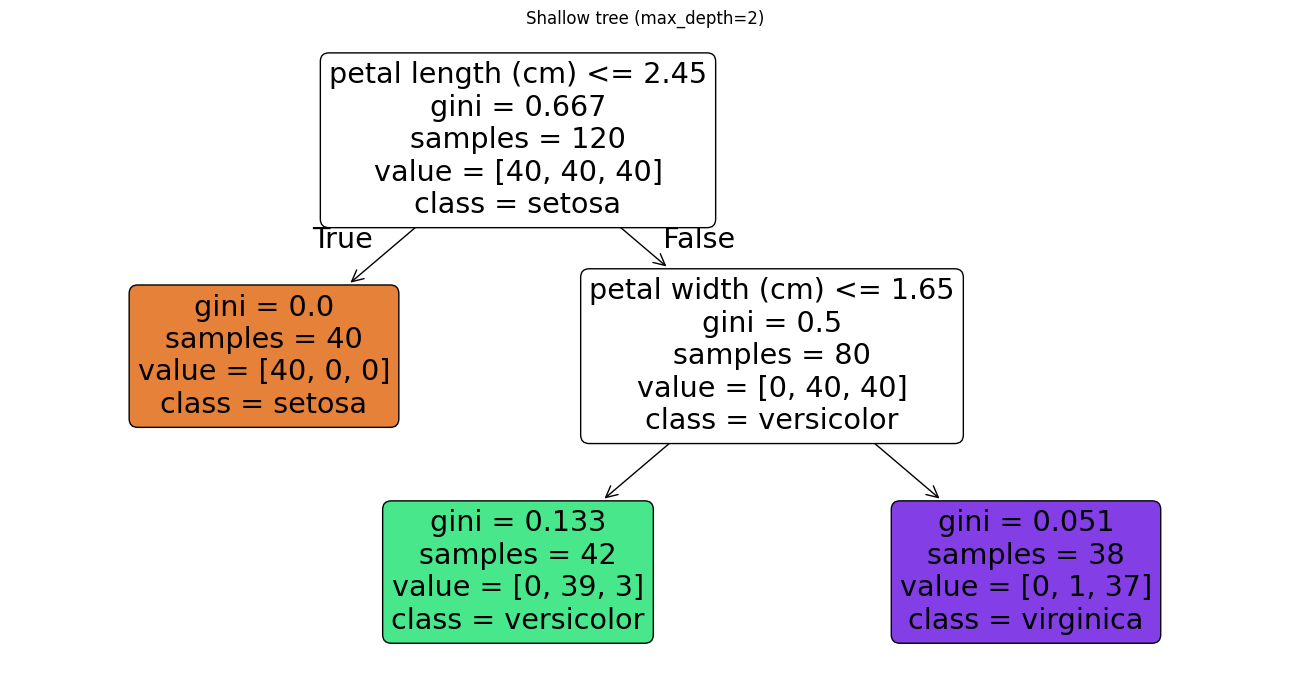

In [3]:
shallow_tree = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE)
shallow_tree.fit(X_development, y_development)

print("첫 질문:", describe_root(shallow_tree))
show_tree(shallow_tree, "Shallow tree (max_depth=2)")

### 상자 읽는 법

| 항목 | 뜻 | 예 |
|---|---|---|
| `feature <= 값` | 이 상자의 질문 | `petal length <= 2.45` |
| `gini` | 섞인 정도 (0이면 한 종류만) | `gini = 0.0` |
| `samples` | 여기까지 온 개수 | `samples = 42` |
| `value` | 클래스별 **개수** | `[0, 39, 3]` → setosa 0, versicolor 39, virginica 3 |
| `class` | 가장 많은 클래스 | `versicolor` |

`value` 순서는 알파벳순임: setosa, versicolor, virginica.

### Prediction 1

개발 데이터의 **세 번째 꽃(`index=2`)** 이 어느 길로 갈까?

- 예상 경로: `____________`
- 도착한 잎의 가장 큰 비율: `____%`

In [4]:
trace_one_flower(shallow_tree, index=2)

꽃 치수: {'sepal length (cm)': 6.8, 'sepal width (cm)': 2.8, 'petal length (cm)': 4.8, 'petal width (cm)': 1.4}
  petal length (cm) <= 2.45?  관측 4.80  →  아니오, 오른쪽
  petal width (cm) <= 1.65?  관측 1.40  →  예, 왼쪽
  도착 잎: {np.str_('setosa'): 0, np.str_('versicolor'): 39, np.str_('virginica'): 3}  (전체 42)
  예측: versicolor  |  predict_proba: [0.     0.9286 0.0714]


<details>
<summary><b>Prediction 1 확인</b></summary>

- `petal length <= 2.45?` → 관측 4.80 → **아니오, 오른쪽**
- `petal width <= 1.65?` → 관측 1.40 → **예, 왼쪽**
- 잎 `[0, 39, 3]`, `39/42 = 92.9%` → **versicolor**
- `predict_proba = [0, 0.9286, 0.0714]` — 손으로 센 그 숫자임

</details>

트리는 답을 외운 표가 아니라 **순서 있는 질문 규칙**임. 그리고 예측은 100% 확신이 아니라 **잎에서 가장 많은 클래스**임.

> **다음 질문**: 트리는 왜 하필 그 첫 질문을 골랐을까?

## Act 2. 좋은 질문 고르기

스무고개에서 첫 질문으로 뭐가 더 좋을까?

- "고양이인가요?"
- "동물인가요?"

**두 번째죠.** 세상이 크게 갈라지니까. 트리도 같은 기준으로 고름.

### Prediction 2

- **A**: `petal length <= 2.45`
- **B**: `sepal length <= 5.00`

어느 쪽이 한 그룹에 같은 종류를 더 많이 모을까? `A / B`

In [5]:
display(split_count_rate(feature_index=2, threshold=2.45))   # A
display(split_count_rate(feature_index=0, threshold=5.00))   # B

,답,전체,setosa,versicolor,virginica,가장 큰 Rate
0,예(왼쪽),40,40,0,0,1.0
1,아니오(오른쪽),80,0,40,40,0.5


,답,전체,setosa,versicolor,virginica,가장 큰 Rate
0,예(왼쪽),25,23,1,1,0.920000
1,아니오(오른쪽),95,17,39,39,0.410526


<details>
<summary><b>Prediction 2 확인</b></summary>

**A.** A의 왼쪽은 setosa `40/40`으로 완전히 한 종류. B의 왼쪽은 `23/25 = 92%`로 깨끗해 보이지만 그룹이 25개로 작고, **오른쪽 95개가 크게 섞임**(Rate 0.41).

</details>

### 이름 붙이기 — 불순도

"섞인 정도"를 숫자로 부르는 이름이 **불순도(impurity)** 임.

깨끗하면(한 종류만) 0, 섞일수록 커짐. 우리가 방금 Count와 Rate로 눈으로 본 걸 숫자 하나로 만든 것뿐임.

### Gini 공식

sklearn 기본값은 **Gini**임.

$$\text{Gini} = 1 - \sum p_i^2 \qquad (p_i = \text{클래스 } i \text{의 비율})$$

곱셈과 뺄셈만 씀.

| 상황 (2클래스) | $p_1, p_2$ | Gini |
|---|---|---:|
| 한쪽만 | 1.0, 0.0 | 0.0 |
| 약간 섞임 | 0.8, 0.2 | 0.32 |
| 반반 | 0.5, 0.5 | 0.5 |

> **꼭 짚을 것**: 위 표의 최대 `0.5`는 **2클래스일 때만**임. Iris는 3클래스라 루트가 `1 - 3×(1/3)² = 0.667`임. 클래스가 C개면 최대는 `1 - 1/C`.

### 양쪽을 크기까지 감안해서 비교

왼쪽 40개와 오른쪽 80개는 무게가 다름. 그래서 그냥 평균이 아니라 **개수에 비례해서** 섞음.

| 질문 | 왼쪽 Gini | 오른쪽 Gini | 크기를 감안한 자식 Gini |
|---|---:|---:|---:|
| A | 0.000 (40개) | 0.500 (80개) | **0.333** |
| B | 0.150 (25개) | 0.631 (95개) | **0.531** |

$$A = \tfrac{40}{120}(0) + \tfrac{80}{120}(0.5) = 0.333 \qquad B = \tfrac{25}{120}(0.150) + \tfrac{95}{120}(0.631) = 0.531$$

부모 `0.667`에서 더 많이 낮춘 **A**가 이김. 트리는 가능한 질문을 전부 시험해보고 이걸 가장 많이 낮추는 하나를 고름.

**Count → Rate → 덜 섞임 → 양쪽을 크기까지 감안해 비교.** 공식보다 이 흐름이 오래감.

## Act 3. 질문을 몇 번까지 허용할까 (`max_depth`)

`max_depth=3`은 **한 경로에서 질문을 최대 3번까지** 허용한다는 뜻임. 이걸 **질문 횟수 제한**이라고 부르겠음.

Act 1에서 versicolor 잎에 virginica가 3개 섞여 있었죠. **질문을 더 하면 그것도 걸러낼 수 있음.** 그럼 무한정 하면 될까?

### Prediction 3

깊이를 `1 → 2 → 3 → 4 → 5 → 8 → 제한 없음`으로 늘리면

- 훈련 데이터(외운 문제) 정답률은? `____________`
- 교차검증 정답률(처음 보는 문제)도 계속 오를까? `____________`

In [6]:
rows = []
for depth in [1, 2, 3, 4, 5, 8, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    correct, mean, std = cv_report(model, X_development, y_development)
    model.fit(X_development, y_development)
    rows.append({"max_depth": str(depth),
                 "train": accuracy_score(y_development, model.predict(X_development)),
                 "cv_correct": correct, "cv_mean": mean, "cv_std": std,
                 "leaves": model.get_n_leaves()})
depth_df = pd.DataFrame(rows)
display(depth_df)

,max_depth,train,cv_correct,cv_mean,cv_std,leaves
0,1,0.666667,80,0.666667,0.000000,2
1,2,0.966667,113,0.941667,0.020412,3
2,3,0.983333,115,0.958333,0.026352,5
3,4,0.991667,113,0.941667,0.020412,7
4,5,1.000000,114,0.950000,0.016667,8
5,8,1.000000,114,0.950000,0.016667,8
6,None,1.000000,114,0.950000,0.016667,8


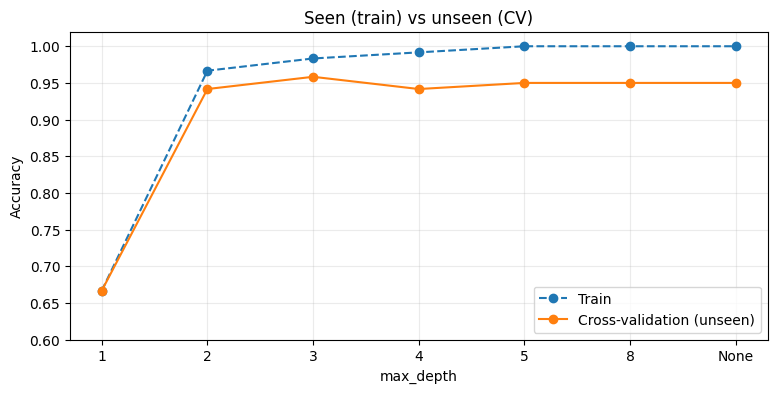

In [7]:
positions = np.arange(len(depth_df))
plt.figure(figsize=(9, 4))
plt.plot(positions, depth_df["train"], "o--", label="Train")
plt.plot(positions, depth_df["cv_mean"], "o-", label="Cross-validation (unseen)")
plt.xticks(positions, depth_df["max_depth"]); plt.ylim(0.6, 1.02)
plt.xlabel("max_depth"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(alpha=.25)
plt.title("Seen (train) vs unseen (CV)"); plt.show()

<details>
<summary><b>Prediction 3 확인</b></summary>

- **train**: `0.667 → 0.967 → 0.983 → 0.992 → 1.000` — 계속 오르다 천장에 붙음
- **CV 정답 개수(처음 보는 문제)**: `80 → 113 → 115 → 113 → 114 → 114 → 114` (/120) — **계속 오르지 않음**

</details>

### 해석

- `max_depth=1`은 질문을 한 번밖에 못 해서 세 종류를 못 나눔. 모델이 너무 단순해서 문제를 못 푸는 상태를 **과소적합**이라고 함.
- 깊이를 늘리면 훈련 정답률은 쉽게 1.0까지 감. 그런데 **처음 보는 데이터는 안 따라옴.** 이 어긋남이 **과적합**임.
- 점선과 실선이 벌어지는 그 간격이 과적합의 모습임.

> **다음 질문**: 깊이가 만드는 경계는 실제로 어떻게 다를까?

## Act 4. 가지치기와 후보 비교

| 파라미터 | 뜻 |
|---|---|
| `max_depth` | 최대 몇 번 질문할 수 있나 |
| `min_samples_split` | **나누기 전** — 최소 몇 개 있어야 더 질문하나 |
| `min_samples_leaf` | **나눠본 뒤** — 자식이 이보다 작아지는 분할은 후보에서 제외 |

둘의 차이가 중요함. `split`은 그냥 멈추고, `leaf`는 **다른 분할을 찾음.**

### Prediction 4

`max_depth=4`(잎 7개)에 `min_samples_split=8`, `min_samples_leaf=4`를 더하면

- 잎은 몇 개? `____개`
- CV 정답 개수(지금 113/120)는 오를까? `____________`

In [8]:
rows = []
for label, model in {
    "depth=4 only": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "depth=4 + split/leaf": DecisionTreeClassifier(
        max_depth=4, min_samples_split=8, min_samples_leaf=4, random_state=RANDOM_STATE),
}.items():
    correct, mean, std = cv_report(model, X_development, y_development)
    model.fit(X_development, y_development)
    rows.append({"candidate": label, "cv_correct": correct,
                 "cv_mean": mean, "cv_std": std, "leaves": model.get_n_leaves()})
display(pd.DataFrame(rows))

,candidate,cv_correct,cv_mean,cv_std,leaves
0,depth=4 only,113,0.941667,0.020412,7
1,depth=4 + split/leaf,113,0.941667,0.020412,5


<details>
<summary><b>Prediction 4 확인</b></summary>

잎 `7 → 5`로 **줄어듦**. CV는 `113 → 113`으로 **변화 없음** (표준편차도 동일).

</details>

트리는 확실히 단순해졌음. 그런데 **처음 보는 데이터를 맞힌 개수는 그대로**임.

**가지치기는 성능을 올려주는 버튼이 아니라 복잡도를 제한하는 도구임.** 트리가 단순해진 것과 새 데이터를 더 잘 맞히게 된 것은 다른 얘기임.

### GridSearchCV — 후보를 같은 계약으로 비교

4회차 KNN에서 쓴 도구를 그대로 씀. 4 × 3 × 3 = **36조합**, 각각 5-Fold라 180번 학습 + `refit` 1번 = 181번.

> **계약**이라는 말을 앞으로 쓰겠음. 비교를 시작하기 전에 미리 정해두는 세 가지임.
> ① 후보를 무엇으로 놓을지 ② 무슨 점수로 잴지 ③ 데이터를 어떻게 나눌지
> **이 셋이 바뀌면 답도 바뀜.** 그래서 결과를 말할 때 계약을 같이 말해야 함.

여기서 나오는 건 "세상에서 제일 좋은 트리"가 아니라 **이 계약 안에서 뽑힌 후보**임.

In [9]:
param_grid = {"max_depth": [2, 3, 4, None],
              "min_samples_split": [2, 4, 8],
              "min_samples_leaf": [1, 2, 4]}
gs = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
                  param_grid, cv=CV, scoring="accuracy", n_jobs=1).fit(X_development, y_development)

cv_df = pd.DataFrame(gs.cv_results_)
n_tied = int((cv_df["rank_test_score"] == 1).sum())
print("선택된 후보:", gs.best_params_)
print(f"CV mean accuracy: {gs.best_score_:.4f}")
print(f"36개 조합 중 공동 1위: {n_tied}개")
assert FINAL_HOLDOUT.open_count == 0

선택된 후보: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
CV mean accuracy: 0.9583
36개 조합 중 공동 1위: 16개


**rank 1이 16개임.** sklearn은 동점일 때 순서상 먼저 나온 걸 돌려줌. 그러니 `best_params_`는 유일한 정답이 아니라 **동점 후보 중 하나**임.

이제 선택을 종료함. 이 뒤로는 선택을 되돌리는 코드가 없음.

In [10]:
best_dt = gs.best_estimator_
FINAL_HOLDOUT.freeze_selection()
print("SELECTION FROZEN")
print("  선택:", gs.best_params_, "| 공동 1위:", n_tied)
print("  지표: accuracy | CV: StratifiedKFold(5, shuffle=True, random_state=42)")

SELECTION FROZEN
  선택: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2} | 공동 1위: 16
  지표: accuracy | CV: StratifiedKFold(5, shuffle=True, random_state=42)


## Act 5. 봉인한 데이터를 한 번만 열기

수업 시작할 때 30개를 봉인했음. 지금까지 `open count = 0`이었고, 이제 엶.

### Prediction 5

30개 중 몇 개를 맞힐 것 같음? `____/30`

**약속 하나.** 결과가 마음에 안 들어도 그걸 보고 모델을 다시 고르지 않음. 시험 문제를 보고 공부 범위를 정하는 것과 같기 때문임.

In [11]:
X_final, y_final = FINAL_HOLDOUT.open_once()
y_pred_final = best_dt.predict(X_final)
final_correct = int((y_pred_final == y_final).sum())
cm_final = confusion_matrix(y_final, y_pred_final)

print(f"FINAL_HOLDOUT: {final_correct}/30 = {final_correct/30:.1%}")
print(f"참고: 30개 평가에서 1건 = {1/30:.1%}p")
print(f"development CV: {gs.best_score_:.1%}")
print(f"open count = {FINAL_HOLDOUT.open_count}")
del X_final, y_final, y_pred_final

FINAL_HOLDOUT: 29/30 = 96.7%
참고: 30개 평가에서 1건 = 3.3%p
development CV: 95.8%
open count = 1


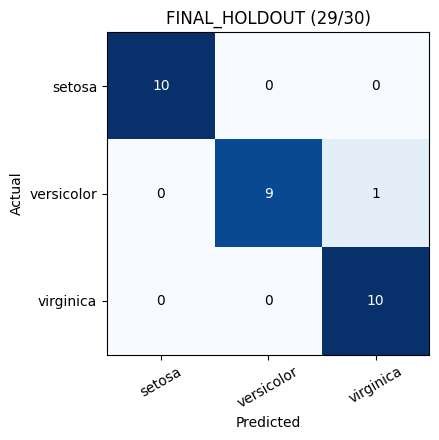

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm_final, cmap="Blues")
for r in range(3):
    for c in range(3):
        ax.text(c, r, cm_final[r, c], ha="center", va="center",
                color="white" if cm_final[r, c] > cm_final.max()/2 else "black")
ax.set_xticks(range(3), target_names, rotation=30); ax.set_yticks(range(3), target_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"FINAL_HOLDOUT ({final_correct}/30)")
plt.tight_layout(); plt.show()

<details>
<summary><b>Prediction 5 확인</b></summary>

`29/30 = 96.7%`. 오분류는 versicolor 1건을 virginica로 예측한 것 하나.

</details>

### 해석

오분류 1건은 **versicolor와 virginica가 겹치는 경계**에서 났음. Act 1에서 본 잎 `[0, 39, 3]`, 그 자리임. setosa는 하나도 안 틀림 — 첫 질문 하나로 완벽히 갈렸으니까.

> **꼭 짚을 것 (오늘 가장 중요)**: 최종 `96.7%`가 CV `95.8%`보다 높게 나왔음. 이걸 "봉인하면 좋아진다"로 읽으면 안 됨. **30개 평가에서 1건이 3.3%p**임. `29/30`과 `28/30`의 차이는 이 크기의 평가에서 흔한 흔들림이지 실력 차이가 아님.
>
> `120개에서 1건 = 0.83%p` / `30개에서 1건 = 3.3%p`

결과가 마음에 안 들어도 같은 데이터를 보며 다시 고르지 않음. 다시 고르려면 **새 평가 데이터**가 필요함.

## Act 6. 선택된 트리 해석하기

점수는 끝났음. 이제 **이미 정해진 트리가 무슨 말을 할 수 있는지**만 읽음. 모델을 바꾸지도, 다시 학습시키지도 않음.

이 트리가 피처 4개를 다 썼을까? 그림과 막대를 같이 봄.

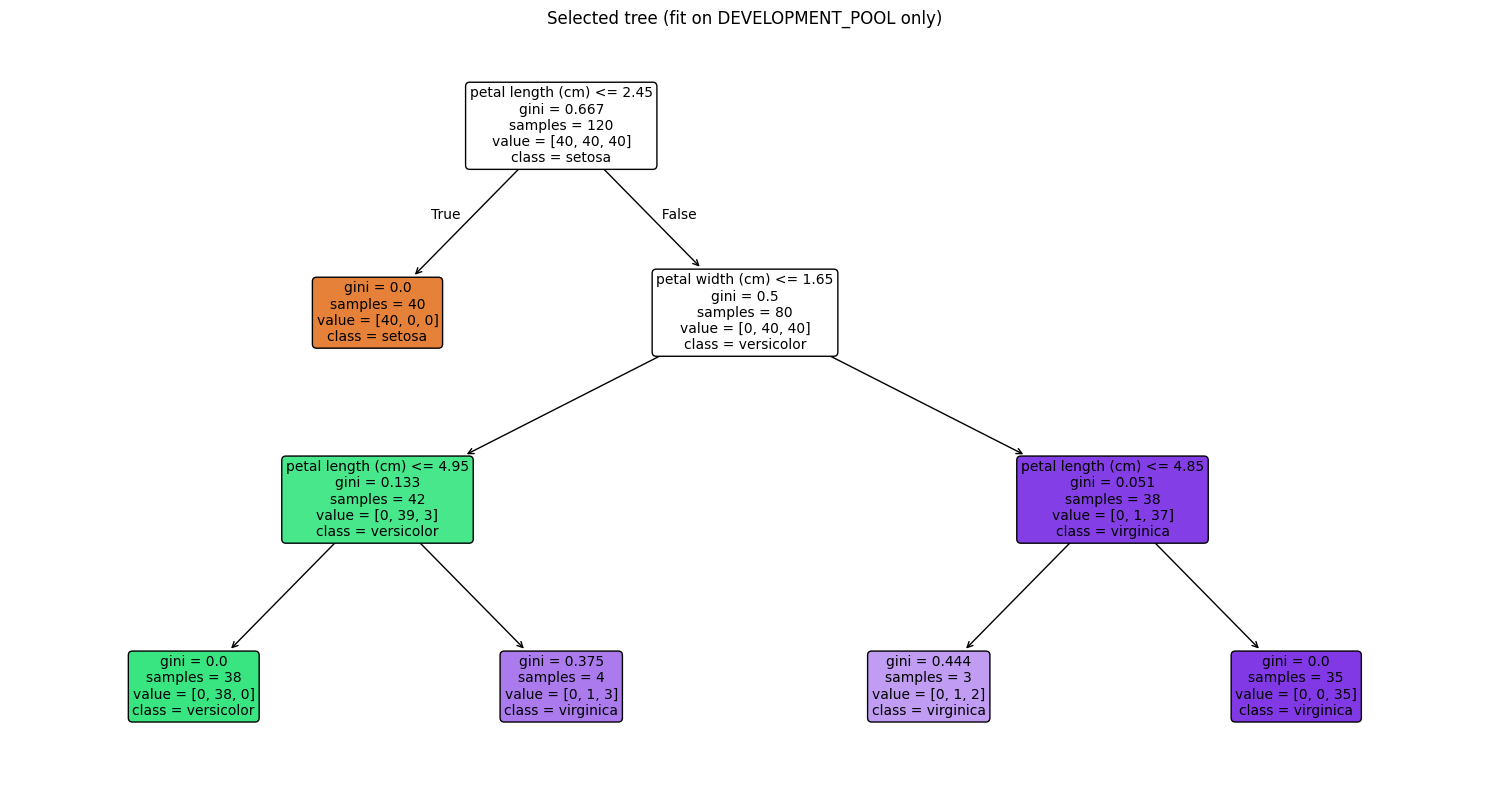

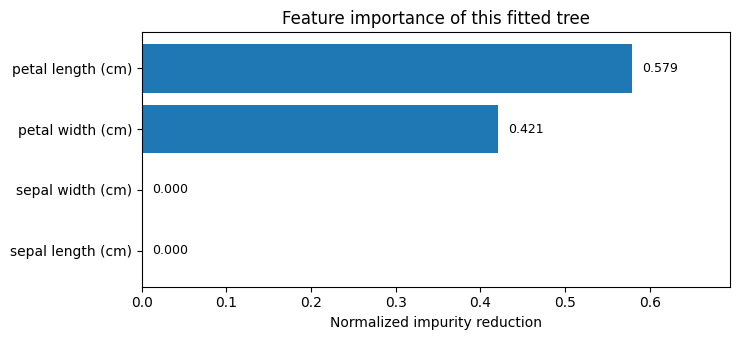

,importance
petal length (cm),0.579077
petal width (cm),0.420923
sepal length (cm),0.000000
sepal width (cm),0.000000


In [13]:
show_tree(best_dt, "Selected tree (fit on DEVELOPMENT_POOL only)", figsize=(15, 8), fontsize=10)

importances = pd.Series(best_dt.feature_importances_, index=feature_names).sort_values()
plt.figure(figsize=(7.5, 3.5))
bars = plt.barh(importances.index, importances.values)
for bar, v in zip(bars, importances.values):
    plt.text(v + .012, bar.get_y() + bar.get_height()/2, f"{v:.3f}", va="center", fontsize=9)
plt.xlim(0, importances.max()*1.2); plt.xlabel("Normalized impurity reduction")
plt.title("Feature importance of this fitted tree"); plt.tight_layout(); plt.show()
display(importances.rename("importance").sort_values(ascending=False).to_frame())


- 사용됨: `petal length (0.579)`, `petal width (0.421)`
- 사용 안 됨: `sepal length (0.000)`, `sepal width (0.000)`

### `0.000`이 뜻하지 않는 것

Feature importance는 이 **특정 트리**가 분기에서 줄인 불순도의 비중임. 다 더하면 1.0. `0`이면 **이 트리의 분기에 안 쓰였다**는 뜻임.

**그런데 "쓸모없다"는 뜻이 아님.** 오늘 이미 두 번 봤음.

- **Act 2**: 질문 B(`sepal length <= 5.00`)가 왼쪽에 setosa를 `23/25 = 92%`까지 모았음
- **Support E**: sepal 두 개**만**으로 처음 보는 꽃 `31/36 = 86.1%`를 맞혔음

**정보가 없는 게 아니라, petal 두 개가 먼저 일을 끝내서 쓸 자리가 없었던 것임.**

> **사용되지 않은 피처 ≠ 중요하지 않은 피처**

비 오는 날 우산을 많이 씁니다. 그럼 우산이 비의 원인인가요? 아니죠. **importance는 원인이 아니라 모델이 많이 쓴 단서**임.

기억할 것 셋: 데이터가 바뀌면 importance도 바뀜 / 비슷한 피처끼리는 중요도를 나눠 가짐 / **인과관계가 아님**.

## Act 7. 한 그루의 흔들림

오늘 우리는 트리 한 그루를 열심히 읽었음. 첫 질문은 `petal length <= 2.45`였음.

그 질문이 얼마나 단단한지 **데이터는 그대로 두고 숫자 하나만 바꿔** 확인함.

지금까지 모든 셀에 `random_state=42`가 있었음. 트리는 if-else인데 왜 랜덤이 필요할까?

**동점 때문임.** 불순도를 똑같이 줄이는 질문이 둘 이상이면 sklearn은 그중 하나를 무작위로 고름.

### Prediction 6

같은 120개, `random_state`만 `0~29`로 바꿔 30그루를 만들면 서로 다른 루트 질문이 몇 가지 나올까? `____가지`


In [14]:
seed_rows = [{"random_state": s, "루트 질문": describe_root(
                 DecisionTreeClassifier(random_state=s).fit(X_development, y_development))}
             for s in range(30)]
display(pd.DataFrame(seed_rows).groupby("루트 질문").size()
        .rename("횟수").sort_values(ascending=False).to_frame())
print("데이터는 단 한 개도 바뀌지 않았음 (같은 120개)")

,횟수
루트 질문,
petal width <= 0.80,22
petal length <= 2.45,8


데이터는 단 한 개도 바뀌지 않았음 (같은 120개)


<details>
<summary><b>Prediction 6 확인</b></summary>

**2가지.** `petal width <= 0.80`이 **22번**, `petal length <= 2.45`가 **8번**.

두 질문 모두 setosa 40개를 똑같이 완벽하게 떼어냄. 불순도 감소가 같아서 sklearn이 무작위로 고름. **잎 수도 train 정답 수도 동일함.**

</details>

**데이터를 하나도 안 바꿨는데 첫 질문이 바뀜.** 그리고 우리가 본 `petal length <= 2.45`는 30번 중 **8번**, 다수파도 아니었음.

성능이 나빠진 건 아님. 두 트리 다 잎 8개, train 120/120임. **같은 데이터를 똑같이 잘 설명하는 규칙이 하나가 아니라는 뜻임.**

읽을 수 있다는 것과 안정적이라는 것은 다름. 트리가 읽히는 이유(딱 잘라 나눔)가 흔들리는 이유이기도 함.

> 실무 한 줄: 트리 그림이나 importance를 보고서에 넣을 때는 **`random_state`를 함께 적어야 함.**

> **Better Question**: 한 그루의 규칙이 흔들린다면, 여러 그루의 판단을 묶었을 때 무엇이 달라질까? 이 확장 실험은 Support F에서 확인함.


## 오늘의 정리

| 개념 | 핵심 |
|---|---|
| 노드 읽기 | 질문 / gini / samples / value / class |
| 불순도 | Count → Rate로 섞임을 보고 Gini로 이름 붙임 |
| 질문 횟수 제한 | **외운 문제 점수와 처음 보는 문제 점수는 따로 논다** |
| 가지치기 | 복잡도 제한 도구 (성능 보장 아님) |
| 후보 비교 | 같은 CV 계약으로, 공동 1위 확인 |
| 최종 평가 | 선택 종료 후 한 번만, 크기를 감안해 읽기 |
| Importance | 이 트리의 불순도 감소 비중 (인과 아님) |
| 불안정성 | 데이터가, 씨앗이 조금 바뀌면 규칙이 바뀜 |

### 회귀에도 같은 트리를 씀

| | 분류 트리 | 회귀 트리 (`DecisionTreeRegressor`) |
|---|---|---|
| 잎에서 | 다수결 | **평균** |
| 좋은 질문 기준 | `gini` (섞임) | `squared_error` (흩어짐) |
| 나머지 | `max_depth`, 가지치기, 과적합, 불안정성 **모두 동일** | |

6회차 회귀 문제도 이 트리로 풀 수 있음.

### 기억할 흐름

```
질문 경로 읽기 → Count/Rate로 섞임 확인 → 불순도라는 이름 붙이기
→ 개발 데이터 CV로 질문 횟수 제한 선택 → 최종 평가는 선택 종료 후 한 번만
→ 선택된 트리만 범위를 지켜 해석 → 한 그루의 흔들림 확인
```

### 다음 수업으로 가져갈 한 문장

다음에 모델을 고를 때, **나는 어떤 증거를 먼저 요구하겠음?**

`__________________________________________________________`

---

# 선택 Support — Core가 아님

시간이 남거나 질문이 나올 때만 엶.

## Support A. Gini와 Entropy

Entropy는 "불확실성의 양"을 재는 다른 방법임. 2클래스 기준 Gini는 0~0.5, Entropy는 0~1.0. 원리는 같음 — 섞이면 크고 깨끗하면 작음.

In [15]:
for name, criterion in [("Gini", "gini"), ("Entropy", "entropy")]:
    correct, mean, _ = cv_report(
        DecisionTreeClassifier(max_depth=3, criterion=criterion, random_state=RANDOM_STATE),
        X_development, y_development)
    print(f"{name:8s}: {correct}/120 = {mean:.1%}")

Gini    : 115/120 = 95.8%
Entropy : 114/120 = 95.0%


`115` vs `114` — **1건 차이**임. 이 폭으로 criterion의 우열을 선언하지 않음. 기본값 Gini를 쓰면 됨.

## Support B. 결측치(NaN)

scikit-learn **1.3부터** `DecisionTreeClassifier`는 이 예제의 기본 설정(`splitter='best'`, `criterion='gini'`)에서 NaN을 직접 처리함.

구현은 거리 계산 여부와 무관함. 학습할 때 각 분기 후보마다 **결측 샘플을 모두 왼쪽으로 보낸 경우와 모두 오른쪽으로 보낸 경우를 평가**하고, 더 나은 방향을 그 분기의 결측값 경로로 기록함. 예측 때도 그 경로를 사용함.

> 이전 자료의 **"sklearn 트리는 NaN을 직접 처리하지 못한다"**와 **"거리를 계산하지 않아서 NaN을 처리한다"**는 설명은 모두 정정함. 지원 범위는 sklearn 버전·estimator·설정에 따라 다르므로 사용 환경의 문서를 확인해야 함.


In [16]:
from sklearn.datasets import make_classification
from sklearn.impute import SimpleImputer

Xm, ym = make_classification(n_samples=300, n_features=4, n_informative=3,
                             n_redundant=0, random_state=RANDOM_STATE)
Xm = Xm.astype(float)
Xm[np.random.RandomState(RANDOM_STATE).rand(*Xm.shape) < 0.10] = np.nan
Xtr, Xte, ytr, yte = train_test_split(Xm, ym, test_size=.3, stratify=ym, random_state=RANDOM_STATE)

native = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(Xtr, ytr)
imp = SimpleImputer(strategy="mean")
filled = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(imp.fit_transform(Xtr), ytr)

print(f"결측 {int(np.isnan(Xm).sum())}개 / 전체 {Xm.size}개")
print(f"NaN 그대로 학습     : {(native.predict(Xte)==yte).sum()}/{len(yte)}")
print(f"SimpleImputer(mean) : {(filled.predict(imp.transform(Xte))==yte).sum()}/{len(yte)}")

결측 128개 / 전체 1200개
NaN 그대로 학습     : 75/90
SimpleImputer(mean) : 76/90


이 실행에서는 native routing이 `75/90`, 평균 대치가 `76/90`으로 **1건 차이**였음. 이 한 번의 결과로 **"채우는 게 항상 낫다"도 "안 채우는 게 낫다"도 말할 수 없음.** 중요한 건 **왜 비었는가**임.

> **다음 실습 예고**: 펭귄에는 진짜 결측치가 있음. 같은 NaN 입력을 이 설정의 트리는 native routing으로 처리하지만, 로지스틱 회귀와 KNN은 별도 전처리 없이 받지 못함. 차이는 **거리 계산 여부가 아니라 각 estimator에 구현된 입력 처리와 결측값 지원 방식**에서 생김.

## Support C. 클래스 불균형과 PR Curve

정상 900건 vs 이상 100건이면 "전부 정상"이라 답해도 정확도 90%임. `class_weight='balanced'`는 소수 클래스 오분류에 벌점을 키움.

precision / recall / PR Curve는 평가지표 회차에서 다뤘음. 여기서는 **트리에 `class_weight`를 걸면 그 지표가 어떻게 움직이나**만 봄.


[no weight] recall 24/31 = 77.4% | precision 24/26 = 92.3% | AP = 0.869
[balanced ] recall 30/31 = 96.8% | precision 30/65 = 46.2% | AP = 0.871


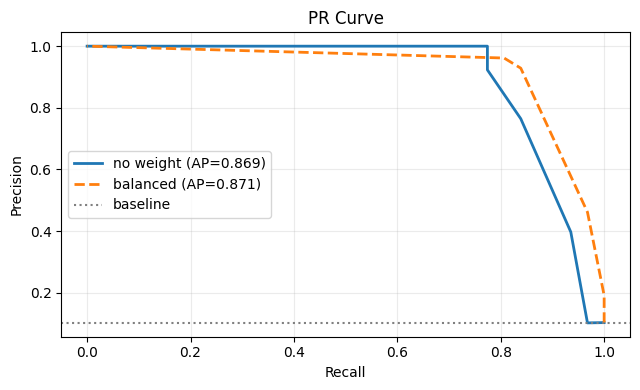

In [17]:
from sklearn.metrics import precision_recall_curve, average_precision_score

Xi, yi = make_classification(n_samples=1000, n_features=4, n_informative=3,
                             n_redundant=0, weights=[0.9, 0.1], random_state=RANDOM_STATE)
Xtr2, Xte2, ytr2, yte2 = train_test_split(Xi, yi, test_size=.3, stratify=yi, random_state=RANDOM_STATE)

plt.figure(figsize=(6.5, 4))
for label, kw, style in [("no weight", {}, "-"), ("balanced", {"class_weight": "balanced"}, "--")]:
    m = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE, **kw).fit(Xtr2, ytr2)
    proba, pred = m.predict_proba(Xte2)[:, 1], m.predict(Xte2)
    tp, n_pos, n_pp = int(((pred==1)&(yte2==1)).sum()), int((yte2==1).sum()), int((pred==1).sum())
    ap = average_precision_score(yte2, proba)
    prec_txt = f"{tp}/{n_pp} = {tp/n_pp:.1%}" if n_pp else "양성 예측 0건"
    print(f"[{label:9s}] recall {tp}/{n_pos} = {tp/n_pos:.1%} | precision {prec_txt} | AP = {ap:.3f}")
    p, r, _ = precision_recall_curve(yte2, proba)
    plt.plot(r, p, style, lw=2, label=f"{label} (AP={ap:.3f})")
plt.axhline(yte2.mean(), ls=":", color="grey", label="baseline")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.grid(alpha=.25)
plt.title("PR Curve"); plt.tight_layout(); plt.show()

`balanced`는 recall을 `77.4% → 96.8%`로 올렸지만 precision은 `92.3% → 46.2%`로 떨어뜨림. AP는 `0.869` vs `0.871`로 사실상 같음.

즉 **분류력을 키운 게 아니라 판단 기준선을 소수 클래스 쪽으로 옮긴 것**에 가까움. **무엇을 놓치면 더 아픈가**를 먼저 정해야 이 선택을 평가할 수 있음.

## Support D. 계약이 바뀌면 선택도 바뀜

이 강의의 이전 버전은 같은 Iris, 같은 grid로 `max_depth=4`를 선택했음. 이번 버전은 `3`임. 다른 건 **fold를 나누는 방식 하나**임.

In [18]:
for label, cv_obj in [("이전: cv=5 (shuffle 없음)", 5),
                      ("이번: StratifiedKFold(5, shuffle=True, 42)", CV)]:
    s = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
                     param_grid, cv=cv_obj, scoring="accuracy", n_jobs=1).fit(X_development, y_development)
    tied = int((pd.DataFrame(s.cv_results_)["rank_test_score"] == 1).sum())
    print(f"{label}\n  → max_depth = {s.best_params_['max_depth']}, "
          f"CV = {s.best_score_:.4f}, 공동 1위 = {tied}개\n")

이전: cv=5 (shuffle 없음)
  → max_depth = 4, CV = 0.9417, 공동 1위 = 2개



이번: StratifiedKFold(5, shuffle=True, 42)
  → max_depth = 3, CV = 0.9583, 공동 1위 = 16개



같은 데이터, 같은 후보, 같은 지표인데 **fold 구성만 바꾸니 선택이 4에서 3으로 바뀜.**

`max_depth=3`은 결정 트리의 정답이 아니라 **이 계약 안에서의 선택**임. 그래서 결과를 공유할 때는 숫자만 주지 말고 **어떤 계약에서 나온 숫자인지**를 함께 줘야 함.

## Support E. 경계 모양 — 깊이가 만드는 차이를 눈으로

경계를 그리려면 피처가 2개여야 함. **Iris의 `sepal length` + `sepal width`** 두 개만 씀.

왜 sepal인가? petal 두 개는 문제가 너무 쉬워서 깊이를 바꿔도 결과가 똑같이 나옴. 트리가 거들떠보지도 않은 sepal로 하면 깊이 차이가 드러남.

개발 데이터 120개를 다시 84 / 36으로 쪼개 씀. 최종 봉투는 안 엶.

Act 3에서 표로 본 걸 그림으로 다시 봄. 숫자가 아니라 **모양**으로 보면 감이 다름.

In [19]:
SEPAL = [0, 1]
X2 = X_development[:, SEPAL]
X2_tr, X2_un, y2_tr, y2_un = train_test_split(
    X2, y_development, test_size=0.30, stratify=y_development, random_state=RANDOM_STATE)

dt_free    = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X2_tr, y2_tr)
dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(X2_tr, y2_tr)

for label, model in [("max_depth=None", dt_free), ("max_depth=3", dt_shallow)]:
    print(f"[{label}] 잎 {model.get_n_leaves():2d} | "
          f"train {(model.predict(X2_tr)==y2_tr).sum()}/84 | "
          f"unseen {(model.predict(X2_un)==y2_un).sum()}/36")

[max_depth=None] 잎 31 | train 82/84 | unseen 26/36
[max_depth=3] 잎  7 | train 69/84 | unseen 31/36


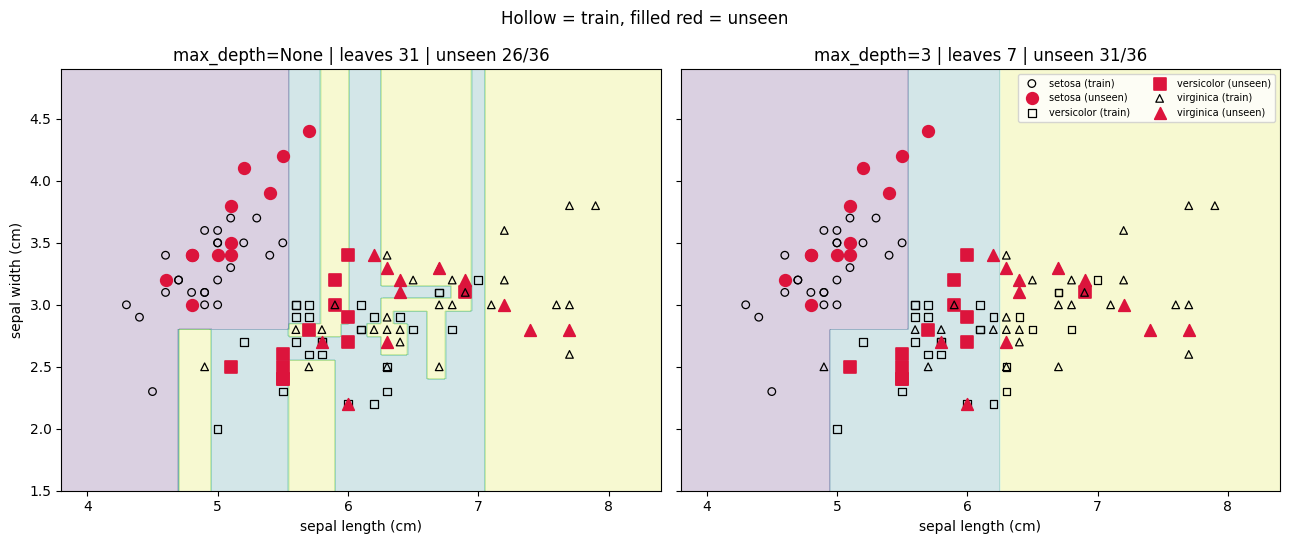

In [20]:
xx, yy = np.meshgrid(np.linspace(X2[:,0].min()-.5, X2[:,0].max()+.5, 300),
                     np.linspace(X2[:,1].min()-.5, X2[:,1].max()+.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
MARKERS = ["o", "s", "^"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, label, model in zip(axes, ["max_depth=None", "max_depth=3"], [dt_free, dt_shallow]):
    ax.contourf(xx, yy, model.predict(grid).reshape(xx.shape), alpha=.20, cmap="viridis")
    for k, (name, mk) in enumerate(zip(target_names, MARKERS)):
        ax.scatter(*X2_tr[y2_tr==k].T, marker=mk, s=30, facecolors="none",
                   edgecolors="black", linewidths=.9, label=f"{name} (train)")
        ax.scatter(*X2_un[y2_un==k].T, marker=mk, s=70, color="crimson",
                   linewidths=1.2, label=f"{name} (unseen)")
    ax.set_title(f"{label} | leaves {model.get_n_leaves()} | "
                 f"unseen {(model.predict(X2_un)==y2_un).sum()}/36")
    ax.set_xlabel(feature_names[0])
axes[0].set_ylabel(feature_names[1]); axes[1].legend(fontsize=7, ncol=2)
plt.suptitle("Hollow = train, filled red = unseen"); plt.tight_layout(); plt.show()

| | 잎 | train | 처음 보는 36개 |
|---|---:|---|---|
| max_depth=None | **31** | 82/84 = 97.6% | 26/36 = 72.2% |
| max_depth=3 | 7 | 69/84 = 82.1% | **31/36 = 86.1%** |

**완전히 뒤집힘.** 훈련에서는 `97.6% - 82.1% = 15.5%p` 앞섰지만, 처음 보는 데이터에서는 `86.1% - 72.2% = 13.9%p` 뒤집힘.

### 해석

훈련 점(속 빈 도형)을 잘 감쌀수록 처음 보는 점(빨간 도형)을 놓침. `82/84 → 26/36`과 `69/84 → 31/36`이 그 교환임.

**경계에 대각선이 하나도 없음.** 트리의 질문은 `이 피처 <= 이 값?` 하나뿐이라 축에 수직인 칼질만 가능함. 그런데 versicolor와 virginica는 비스듬히 섞여 있어서, 트리는 **계단을 여러 개 이어 붙여 사선을 흉내** 냄. 잎이 31개까지 간 이유가 이것임.

| | 사선 경계를 만나면 |
|---|---|
| 로지스틱 회귀 | 직선 하나로 그음 |
| 결정 트리 | 계단으로 **흉내** → 깊이를 많이 씀 → **과적합 위험** |

> 여기 쓴 sepal 두 개는 Act 6에서 importance가 **0.000**으로 나온 피처임. 그런데 sepal만으로도 `31/36`을 맞혔음.

## Support F. 여러 트리 다수결 — 흔들림의 폭 보기

Core에서는 한 그루의 규칙이 씨앗에 따라 달라지는 데서 멈췄음. 여기서는 **DEVELOPMENT_POOL만 복원추출**해 트리 6그루를 만들고, 다수결을 20번 반복함. `FINAL_HOLDOUT`은 다시 열지 않음.

### Prediction F

- 단독 트리 120그루의 정답 수 표준편차는 얼마일까? `____`
- 6그루 다수결 20회의 표준편차는 그보다 클까, 작을까? `____________`

이 실험은 다음 앙상블 회차로 가는 선택 확장임. 결정 트리 Core의 필수 흐름은 아님.


,대상,평균,표준편차,최저,최고
0,단독 트리 120그루,116.266667,1.515109,111,119
1,6그루 다수결 20회,117.350000,0.792149,116,119


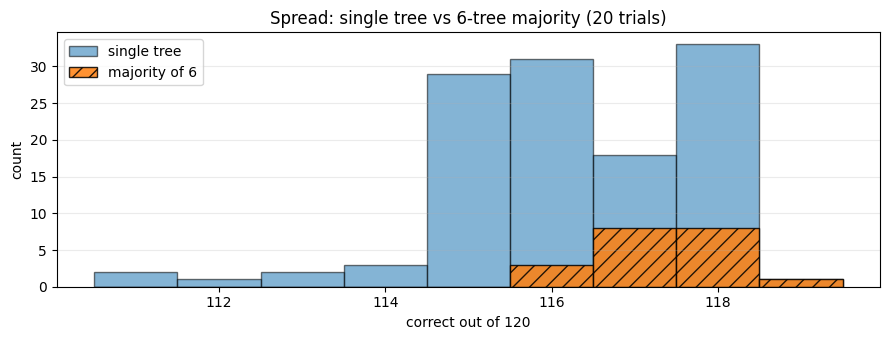

In [21]:
single_scores, ensemble_scores = [], []

for seed in range(20):
    rng_trial = np.random.RandomState(seed)
    trial_preds = []
    for _ in range(6):
        index = rng_trial.choice(len(X_development), len(X_development), replace=True)
        model = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
        model.fit(X_development[index], y_development[index])
        single = model.predict(X_development)
        trial_preds.append(single)
        single_scores.append(int((single == y_development).sum()))

    trial_matrix = np.vstack(trial_preds)
    trial_majority = np.array([
        np.bincount(trial_matrix[:, j], minlength=len(target_names)).argmax()
        for j in range(trial_matrix.shape[1])
    ])
    ensemble_scores.append(int((trial_majority == y_development).sum()))

single_scores = np.array(single_scores)
ensemble_scores = np.array(ensemble_scores)

ensemble_summary = pd.DataFrame([
    {"대상": f"단독 트리 {len(single_scores)}그루", "평균": single_scores.mean(),
     "표준편차": single_scores.std(), "최저": single_scores.min(), "최고": single_scores.max()},
    {"대상": f"6그루 다수결 {len(ensemble_scores)}회", "평균": ensemble_scores.mean(),
     "표준편차": ensemble_scores.std(), "최저": ensemble_scores.min(), "최고": ensemble_scores.max()},
])
display(ensemble_summary)

bins = np.arange(single_scores.min() - .5, single_scores.max() + 1.5, 1)
plt.figure(figsize=(9, 3.5))
plt.hist(single_scores, bins=bins, alpha=.55, label="single tree", edgecolor="black")
plt.hist(ensemble_scores, bins=bins, alpha=.85, label="majority of 6",
         edgecolor="black", hatch="//")
plt.xlabel("correct out of 120"); plt.ylabel("count"); plt.legend(); plt.grid(alpha=.25, axis="y")
plt.title("Spread: single tree vs 6-tree majority (20 trials)"); plt.tight_layout(); plt.show()

assert FINAL_HOLDOUT.open_count == 1


### Support F 결과 — 평균보다 흔들림

| | 평균 | 표준편차 | 최저 | 최고 |
|---|---:|---:|---:|---:|
| 단독 트리 120그루 | 116.27 | **1.52** | **111** | 119 |
| 6그루 다수결 20회 | 117.35 | **0.79** | **116** | 119 |

**최고점은 `119`로 똑같음. 달라진 건 바닥임.** 단독으로는 운 나쁘면 `111`을 뽑는데, 다수결에는 그 꼬리가 없음.

즉 이 실험에서 다수결이 산 것은 "언제나 더 높은 점수"가 아니라 **운 나쁜 트리를 뽑을 위험을 줄인 것**에 가까움. 이 결과 하나를 앙상블 전체의 보편 법칙으로 확대하지 않음.

그리고 어느 그루가 `119`짜리인지는 미리 알 수 없음. 알려면 정답을 봐야 하고, **정답을 보고 고르면 시험지를 보고 공부 범위를 정한 것**임. Act 5에서 봉투를 봉인한 이유가 정확히 그거였음.

> **다음 질문**: 흔들림을 줄이는 게 목적이라면 그루를 몇 개까지 늘려야 할까? 그 대가로 무엇을 잃을까?

잃는 것 하나는 이미 정해져 있음. **Act 1에서 손으로 읽었던 그 규칙을 더 이상 한 장의 그림으로 읽을 수 없음.**


---

# Closing Support — 세 모델을 같은 개발 계약으로 다시 보기

이 셀은 **선택을 다시 하는 단계가 아님.** `SELECTION FROZEN`과 `FINAL_HOLDOUT 1회`가 끝난 뒤, 지난 두 회차의 모델을 같은 `DEVELOPMENT_POOL`·같은 CV로 회고 비교함.

- `best_dt`를 바꾸지 않음
- `FINAL_HOLDOUT`을 다시 열지 않음
- 최종 점수를 새로 만들지 않음

로지스틱 회귀와 KNN에는 스케일러를 붙여 비교 조건을 맞춤.

돌리기 전에: **셋 중 누가 이길 것 같음?**


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

holdout_open_count_before_closing_support = FINAL_HOLDOUT.open_count
rows = []
for name, model in {
    "LogisticRegression(+Scaler)": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    "KNN k=5 (+Scaler)": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "DecisionTree(max_depth=3)": DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
}.items():
    correct, mean, std = cv_report(model, X_development, y_development)
    rows.append({"model": name, "cv_correct": correct, "cv_mean": mean, "cv_std": std})
closing_model_comparison = pd.DataFrame(rows)
display(closing_model_comparison)

assert best_dt is gs.best_estimator_
assert FINAL_HOLDOUT.open_count == holdout_open_count_before_closing_support == 1
print("선택 변경 없음 / FINAL_HOLDOUT 재개봉 없음")


,model,cv_correct,cv_mean,cv_std
0,LogisticRegression(+Scaler),115,0.958333,0.026352
1,KNN k=5 (+Scaler),115,0.958333,0.026352
2,DecisionTree(max_depth=3),115,0.958333,0.026352


선택 변경 없음 / FINAL_HOLDOUT 재개봉 없음


### 셋이 똑같이 나옴

`115/120 = 95.8%`, 표준편차까지 동일함. **이 CV 결과만으로는 Iris에서 세 모델의 성적을 구분할 수 없음.**

그럼 왜 트리를 배웠나? **점수뿐 아니라 판단 규칙을 어떤 형태로 읽을 수 있는지도 다르기 때문임.**

| | 판단 근거로 꺼낼 수 있는 것 |
|---|---|
| 로지스틱 회귀 | 계수 12개 (3클래스 × 4피처) + 절편 3개 |
| KNN | 특정 예측의 이웃은 확인할 수 있지만 **전역 규칙으로 한 장에 요약하기 어려움** |
| **결정 트리** | **질문 경로와 트리 그림** |

Act 1에서 꽃 한 송이가 잎까지 가는 길을 손으로 따라간 방식은 트리의 대표적인 장점임.

> 단, Iris 한 데이터와 이 CV 계약에서의 결과임. 데이터나 계약이 바뀌면 순위도 바뀔 수 있음.


## 비교표

| 비교 | 로지스틱 | KNN | 결정 트리 |
|---|:---:|:---:|:---:|
| 판단 기준 | 확률 | 거리 | 규칙 (if-else) |
| 경계 모양 | 직선 | 곡선 | **축 평행 계단** |
| 해석력 | 계수 12개 | 특정 이웃 확인 가능, **전역 규칙 요약은 어려움** | **질문 경로·그림으로 읽음** |
| 안정성 | 비교적 안정 | K에 따라 변동 | **규칙이 씨앗에 따라 흔들림 (Core Act 7)** |
| 피처 중요도 | 계수 | 별도 도구 | `feature_importances_` (이 트리 기준) |
| 과적합 제어 | C | K | `max_depth`, `min_samples_*` |

**아직 근거가 없는 칸 세 개**: 스케일링 / 고차원 거동 / 학습 속도. 이 노트북에서 확인하지 않았음.

스케일링을 Iris로 확인하지 않는 이유가 있음 — 피처 4개가 전부 cm라 **스케일 차이가 거의 없어서** KNN조차 잘 안 변함. 펭귄은 그램과 밀리미터가 섞여 있어 차이가 극적임. **다음 실습에서 직접 확인함.**

> 데이터가 보여주지 못하는 것을 말로 채우지 않고, 보여줄 수 있는 데이터로 미루는 것이 이 표의 원칙임.
